# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from neuroposasic.data import load_dataset, preprocess_data
from neuroposasic.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from neuroposasic.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope
from hgq.utils import trace_minmax

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

In [52]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [53]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [54]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [55]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='qat', patience=30, track_ebops=True)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  - FreeEBOPs
  - TerminateOnNaN


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [56]:
with (
    QuantizerConfigScope(
        place='weight', k0=1, b0=16, i0=8,
        default_q_type='kbi', overflow_mode='sat_sym'
    ),
    QuantizerConfigScope(
        place='datalane', k0=1, i0=8, f0=8,
        default_q_type='kif', overflow_mode='wrap'
    ),
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()
check_layer_trainable_params(model_qat)

Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 12)       │           676 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 12)       │         6,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 20)       │         9,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           316 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,824 (52.89 KB)

 Trainable params: 11,674 (45.60 KB)

 Non-trainable params: 5,150 (7.29 KB)

### Training

Epoch 1/500


I0000 00:00:1777554526.041874   35797 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1463587__.53


49/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3545 - loss: 86.7703

I0000 00:00:1777554529.582777   35797 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1463587__.53


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3607 - loss: 86.6451
Epoch 1: val_loss improved from None to 1.05845, saving model to best_qat_model.keras

Epoch 1: finished saving model to best_qat_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.3926 - loss: 85.7548 - val_accuracy: 0.4612 - val_loss: 1.0585 - learning_rate: 0.0010 - ebops: 8066060.0000
Epoch 2/500
47/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4872 - loss: 81.6822
Epoch 2: val_loss improved from 1.05845 to 0.90344, saving model to best_qat_model.keras

Epoch 2: finished saving model to best_qat_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5259 - loss: 81.6359 - val_accuracy: 0.5743 - val_loss: 0.9034 - learning_rate: 0.0010 - ebops: 8066060.0000
Epoch 3/500
51/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5900 - loss: 81.0351
Epoch 3: val_loss improved from 0.90344 to 0.80589, saving model to best_qat_model.keras

Epoch 3: finished saving model to best_qat_model.

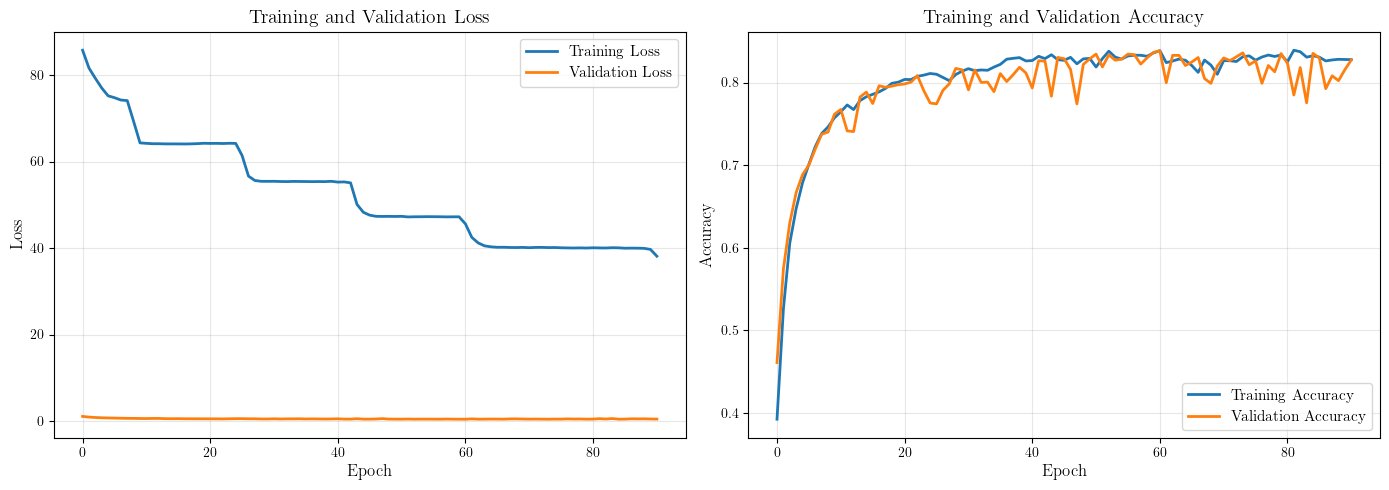

In [57]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2024, epochs=500)
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

### Post-Training: Trace Min-Max

**Critical step before hls4ml conversion.**

When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. This is done by tracing the model on representative data from both the training and validation sets.

In [58]:
trace_minmax(model_qat, X_train)
trace_minmax(model_qat, X_val, reset=False)

4249632

## Model Evaluation

In [59]:
class_report_metric(model_qat, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.4129
  Accuracy: 83.50%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.8705    0.8273    0.8483     40000
   lateral_R     0.8726    0.7873    0.8278     40000
      supine     0.7760    0.8905    0.8293     40001

    accuracy                         0.8350    120001
   macro avg     0.8397    0.8350    0.8352    120001
weighted avg     0.8397    0.8350    0.8352    120001



## Model Saving

In [60]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 16,824
